In [1]:
import torch
import pickle
from utils import DATA_DIR, select_gpu, torch_or_pickle_load
from utils import tree_to_device


print("cuda:", torch.cuda.is_available())
device = select_gpu(1)
print(device)
# we load vocabularies associated to the tensor
vocab = torch_or_pickle_load(DATA_DIR/"tensors/fineweb_dutch_vectors_ids/vocabularies_750.pkl")

vocab_v = vocab["vocab_v"]
vocab_s = vocab["vocab_s"]
vocab_o = vocab["vocab_o"]
v2i = vocab["v2i"]
s2i = vocab["s2i"]
o2i = vocab["o2i"]

# we load in the different tensors
tensor_counting = torch_or_pickle_load(
    DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/counting_1000d_100r_1000i.pkl", map_location=device)
tensor_sc = torch_or_pickle_load(
    DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/sc_1000d_100r_1000i.pkl", map_location=device)
tensor_sii = torch_or_pickle_load(
    DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/sii_1000d_100r_1000i.pkl", map_location=device)

# we move all tensors and matrices to the correct gpu_id


cuda: True
cuda:1


In [2]:
dir = DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/sc_1000d_100r_1000i.pkl"
with open(dir, "rb") as f:
    tensor = pickle.load(f)
# we now save it as a torch loading object instead
save_dir = DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/sc_1000d_100r_1000i.pt"

In [5]:
# we check if we can map the whole tensor to device
tensor_gpu = tree_to_device(tensor, device)
tensor_cpu = tree_to_device(tensor, "cpu")
# we save this as a torch tensor .pt
torch.save(tensor_cpu, save_dir)

In [3]:
def torch_or_pickle_load(path, map_location="cpu"):
    """Tries to load a torch-saved file, if fails, tries pickle."""
    try:
        elements = torch.load(path, map_location=map_location, weights_only=False)
        return elements
        # Move tensors to the specified device if not CPU
        device = torch.device(map_location)

    except RuntimeError as e:
        with open(path, "rb") as f:
            return pickle.load(f)
tensor = torch_or_pickle_load(DATA_DIR/"tensors/fineweb_dutch_vectors_ids/decomposition/counting_1000d_100r_1000i.pkl", map_location=device)

/home/pricie/stefa/.conda/envs/ccl/lib/python3.12/site-packages/torch/_weights_only_unpickler.py:552: UserWarning: Detected pickle protocol 4 in the checkpoint, which was not the default pickle protocol used by `torch.load` (2). The weights_only Unpickler might not support all instructions implemented by this protocol, please file an issue for adding support if you encounter this.
  warnings.warn(


UnpicklingError: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Unsupported operand 149

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

In [2]:
# we perform Tucker Decomposition using tensorly
import tensorly as tl
from tensorly.decomposition import tucker, non_negative_tucker, non_negative_tucker_hals
# ensure float32 and move to GPU (if they are numpy arrays)
tensor_counting = torch.as_tensor(tensor_counting, dtype=torch.float32, device='cuda')
tensor_sc  = torch.as_tensor(tensor_sc,  dtype=torch.float32, device='cuda')
tensor_sii = torch.as_tensor(tensor_sii, dtype=torch.float32, device='cuda')

In [5]:
import inspect
import sys, io, re
from contextlib import contextmanager

def decompose(tensor, non_negative=True, hals=True, rank=None, **kwargs):
    if rank is None:
        rank = [100, 100, 100]
    tic = time.time()

    if not non_negative:
        decomp = tucker
    elif hals:
        decomp = non_negative_tucker_hals
    else:
        decomp = non_negative_tucker


    # figure out what kwargs this function actually accepts
    sig = inspect.signature(decomp)
    allowed_params = sig.parameters.keys()

    # keep only the kwargs that are valid for this specific function
    filtered_kwargs = {k: v for k, v in kwargs.items() if k in allowed_params}


    core, factors = decomp(tensor, rank=rank, **filtered_kwargs)
    toc = time.time()
    print("Time taken for decomposition", toc-tic)
    return core, factors

# some shenanigans to show iteration numbers live


_NUM = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][+-]?\d+)?"

class IterPrefixer(io.TextIOBase):
    def __init__(self, orig, on_iter=None, autoflush=True):
        self.orig = orig
        self.buf = ""
        self.iter = 0
        self.on_iter = on_iter
        self.autoflush = autoflush
        # NOTE: no lookahead at the end; we'll strip punctuation when parsing
        self._regex = re.compile(
            rf"reconstruction\s*error\s*=\s*({_NUM})\s*,\s*variation\s*=\s*({_NUM})",
            re.IGNORECASE,
        )

    def write(self, s):
        self.buf += s
        # robust line handling (supports mixed \n / \r\n / partial lines)
        while True:
            nl = self.buf.find("\n")
            if nl == -1:
                break
            line = self.buf[:nl]
            self.buf = self.buf[nl+1:]

            m = self._regex.search(line)
            if m:
                self.iter += 1
                err_str = m.group(1).rstrip(".,;: ")
                var_str = m.group(2).rstrip(".,;: ")
                try:
                    err = float(err_str)
                    var = float(var_str)
                except ValueError:
                    err = var = None  # fail-safe
                if self.on_iter and (err is not None) and (var is not None):
                    try:
                        self.on_iter(self.iter, err, var)
                    except Exception:
                        pass
                line = f"[iter {self.iter:03d}] " + line

            self.orig.write(line + "\n")
            if self.autoflush:
                try: self.orig.flush()
                except Exception: pass
        return len(s)

    def flush(self):
        if self.buf:
            # write any trailing partial line as-is
            self.orig.write(self.buf)
            self.buf = "\r"
        try: self.orig.flush()
        except Exception: pass

@contextmanager
def live_iteration_numbers(on_iter=None):
    old_stdout, old_stderr = sys.stdout, sys.stderr
    pref_out = IterPrefixer(old_stdout, on_iter=on_iter, autoflush=True)
    pref_err = IterPrefixer(old_stderr, on_iter=on_iter, autoflush=True)
    sys.stdout, sys.stderr = pref_out, pref_err
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

Time taken for decomposition 101.43453812599182
Time taken for decomposition 105.11928033828735


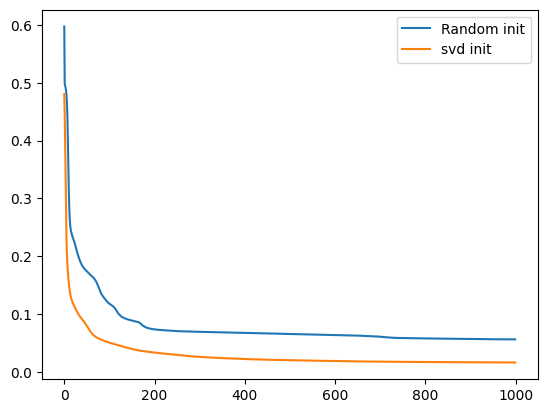

In [37]:
import matplotlib.pyplot as plt
with live_iteration_numbers():
    n_iter_max = 1000
    rank = [100, 100, 100]
    tol = 1e-12
    verbose = False
    (core_a, factors_a), errors_a = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="random", tol=tol, verbose=verbose, return_errors=True
    )
    (core_b, factors_b), errors_b = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )

# we now have a list of tensors of dim 0: we transform them into a list of floats
errors_a = [float(err) for err in errors_a]
errors_b = [float(err) for err in errors_b]

# we plot a and b as different colors
plt.plot(errors_a, label="Random init")
plt.plot(errors_b, label="svd init")
plt.legend()
# we also print the final error values
print("Final error random init:", errors_a[-1])
print("Final error svd init:", errors_b[-1])
plt.show()

[iter 001] reconstruction error=0.49429985880851746, variation=0.003120630979537964.
[iter 002] reconstruction error=0.4905676543712616, variation=0.0037322044372558594.
[iter 003] reconstruction error=0.48505935072898865, variation=0.005508303642272949.
[iter 004] reconstruction error=0.47634008526802063, variation=0.008719265460968018.
[iter 005] reconstruction error=0.4619343876838684, variation=0.014405697584152222.
[iter 006] reconstruction error=0.4381445050239563, variation=0.02378988265991211.
[iter 007] reconstruction error=0.4023231565952301, variation=0.035821348428726196.
[iter 008] reconstruction error=0.3585352301597595, variation=0.04378792643547058.
[iter 009] reconstruction error=0.3164668083190918, variation=0.042068421840667725.
[iter 010] reconstruction error=0.2843337059020996, variation=0.03213310241699219.
[iter 011] reconstruction error=0.2646840214729309, variation=0.0196496844291687.
[iter 012] reconstruction error=0.25316154956817627, variation=0.011522471904

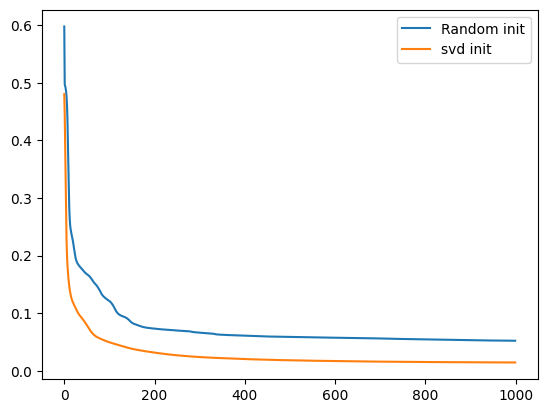

In [38]:
with live_iteration_numbers():
    n_iter_max = 1000
    rank = [150, 150, 150]
    tol = 1e-12
    verbose = True
    (core_a, factors_a), errors_a = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="random", tol=tol, verbose=verbose, return_errors=True
    )
    (core_b, factors_b), errors_b = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )

# we now have a list of tensors of dim 0: we transform them into a list of floats
errors_a = [float(err) for err in errors_a]
errors_b = [float(err) for err in errors_b]

# we plot a and b as different colors
plt.plot(errors_a, label="Random init")
plt.plot(errors_b, label="svd init")
# we also print the final error values
print("Final error random init:", errors_a[-1])
print("Final error svd init:", errors_b[-1])
plt.legend()
plt.show()

[iter 001] reconstruction error=0.26991358399391174, variation=0.10051792860031128.
[iter 002] reconstruction error=0.24807031452655792, variation=0.02184326946735382.
[iter 003] reconstruction error=0.2285342663526535, variation=0.01953604817390442.
[iter 004] reconstruction error=0.2041378617286682, variation=0.02439640462398529.
[iter 005] reconstruction error=0.1919676959514618, variation=0.012170165777206421.
[iter 006] reconstruction error=0.1756528913974762, variation=0.016314804553985596.
[iter 007] reconstruction error=0.1653398871421814, variation=0.0103130042552948.
[iter 008] reconstruction error=0.1580020934343338, variation=0.007337793707847595.
[iter 009] reconstruction error=0.15216848254203796, variation=0.005833610892295837.
[iter 010] reconstruction error=0.14853626489639282, variation=0.0036322176456451416.
[iter 011] reconstruction error=0.14596125483512878, variation=0.002575010061264038.
[iter 012] reconstruction error=0.143615260720253, variation=0.0023459941148

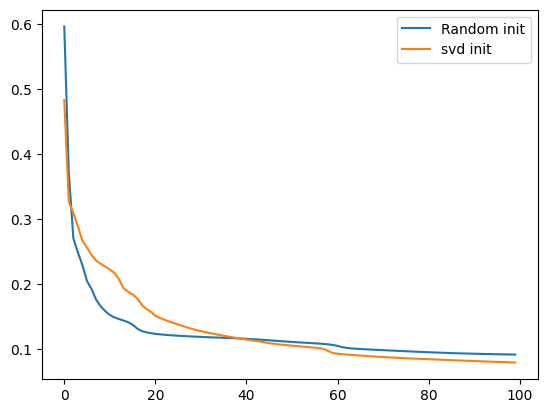

In [39]:
with live_iteration_numbers():
    n_iter_max = 100
    rank = [150, 150, 150]
    tol = 1e-12
    verbose = True
    (core_h_a, factors_h_a), errors_h_a = decompose(
        tensor_counting, non_negative=True, hals=True,
        rank=rank, n_iter_max=n_iter_max, init="random", tol=tol, verbose=verbose, return_errors=True
    )
    (core_h_b, factors_h_b), errors_h_b = decompose(
        tensor_counting, non_negative=True, hals=True,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )

# we now have a list of tensors of dim 0: we transform them into a list of floats
errors_h_a = [float(err) for err in errors_h_a]
errors_h_b = [float(err) for err in errors_h_b]

# we plot a and b as different colors
plt.plot(errors_h_a, label="Random init")
plt.plot(errors_h_b, label="svd init")
# we also print the final error values
print("Final error random init:", errors_h_a[-1])
print("Final error svd init:", errors_h_b[-1])
plt.legend()
plt.show()

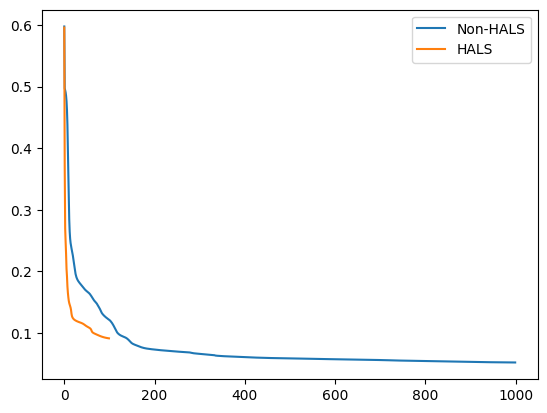

In [40]:
# we also plot errors_a and errors_h_a together to compare hals vs non-hals
plt.plot(errors_a, label="Non-HALS")
plt.plot(errors_h_a, label="HALS")
plt.legend()
plt.show()

# Results, notes, analysis
Starting with an SVD init clearly helps convergence in multiple ways, along all settings.
- Better initial values
- Similar convergence speed (none reach tol and iters take similar time)
- Lower final error !-> Careful with overfitting here
Hals takes a LOT longer per iteration
- inspecting GPU / cpu usage, hals seems to use way less GPU, more CPU
    - 100 iterations on hals = 750 seconds
    - 100 iterations on non-hals = 8 seconds
    - 1000 iterations on non-hals = 100 seconds


[iter 001] reconstruction error=0.3899095952510834, variation=0.05487826466560364.
[iter 002] reconstruction error=0.32885780930519104, variation=0.061051785945892334.
[iter 003] reconstruction error=0.27135196328163147, variation=0.05750584602355957.
[iter 004] reconstruction error=0.22861163318157196, variation=0.04274033010005951.
[iter 005] reconstruction error=0.20128509402275085, variation=0.027326539158821106.
[iter 006] reconstruction error=0.18409672379493713, variation=0.01718837022781372.
[iter 007] reconstruction error=0.1718192845582962, variation=0.01227743923664093.
[iter 008] reconstruction error=0.16210460662841797, variation=0.009714677929878235.
[iter 009] reconstruction error=0.15401050448417664, variation=0.008094102144241333.
[iter 010] reconstruction error=0.14707760512828827, variation=0.006932899355888367.
[iter 011] reconstruction error=0.14121122658252716, variation=0.005866378545761108.
[iter 012] reconstruction error=0.13630923628807068, variation=0.0049019

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

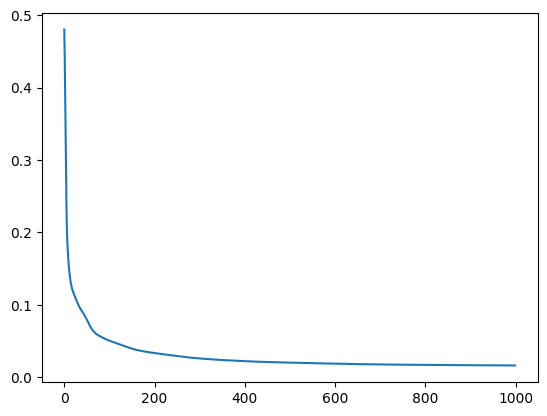

In [6]:
import matplotlib.pyplot as plt
with live_iteration_numbers():
    n_iter_max = 1000
    rank = [100, 100, 100]
    tol = 1e-12
    verbose = True
    (core_reg, factors_reg), errors_reg = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )
    (core_hals, factors_hals), errors_hals = decompose(
        tensor_counting, non_negative=True, hals=True,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )


Final error svd non-hals: 0.016327885910868645
Final error svd hals: 0.022082999348640442


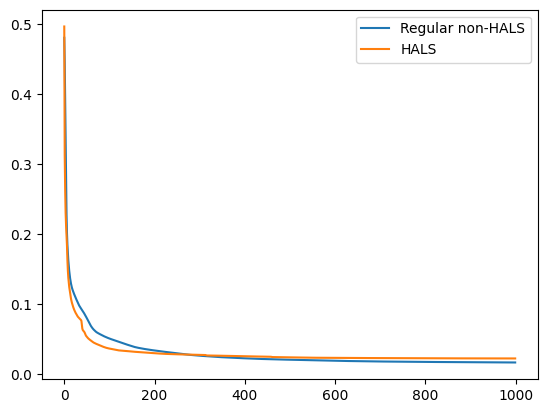

In [29]:
# we now have a list of tensors of dim 0: we transform them into a list of floats
# we first push them to cpu

errors_reg = [float(err) for err in errors_reg]
errors_hals = [float(err) for err in errors_hals]

# we plot a and b as different colors
plt.plot(errors_reg, label="Regular non-HALS")
plt.plot(errors_hals, label="HALS")
plt.legend()
# we also print the final error values
print("Final error svd non-hals:", errors_reg[-1])
print("Final error svd hals:", errors_hals[-1])
plt.show()
# we save the tensors and factors for later analysis
import pickle
with open(DATA_DIR/"tensors/tucker_decomposition_reg_count_100d_1000i.pkl", "wb") as f:
    pickle.dump((core_reg, factors_reg), f)
with open(DATA_DIR/"tensors/tucker_decomposition_hals_count_100d_1000i.pkl", "wb") as f:
    pickle.dump((core_hals, factors_hals), f)


In [38]:
with live_iteration_numbers():
    n_iter_max = 2500
    rank = [100, 100, 100]
    tol = 1e-10
    verbose = True
    (core_reg, factors_reg), errors_reg = decompose(
        tensor_counting, non_negative=True, hals=False,
        rank=rank, n_iter_max=n_iter_max, init="svd", tol=tol, verbose=verbose, return_errors=True
    )

[iter 001] reconstruction error=0.3899095952510834, variation=0.05487826466560364.
[iter 002] reconstruction error=0.32885780930519104, variation=0.061051785945892334.
[iter 003] reconstruction error=0.27135196328163147, variation=0.05750584602355957.
[iter 004] reconstruction error=0.22861163318157196, variation=0.04274033010005951.
[iter 005] reconstruction error=0.20128509402275085, variation=0.027326539158821106.
[iter 006] reconstruction error=0.18409672379493713, variation=0.01718837022781372.
[iter 007] reconstruction error=0.1718192845582962, variation=0.01227743923664093.
[iter 008] reconstruction error=0.16210460662841797, variation=0.009714677929878235.
[iter 009] reconstruction error=0.15401050448417664, variation=0.008094102144241333.
[iter 010] reconstruction error=0.14707760512828827, variation=0.006932899355888367.
[iter 011] reconstruction error=0.14121122658252716, variation=0.005866378545761108.
[iter 012] reconstruction error=0.13630923628807068, variation=0.0049019

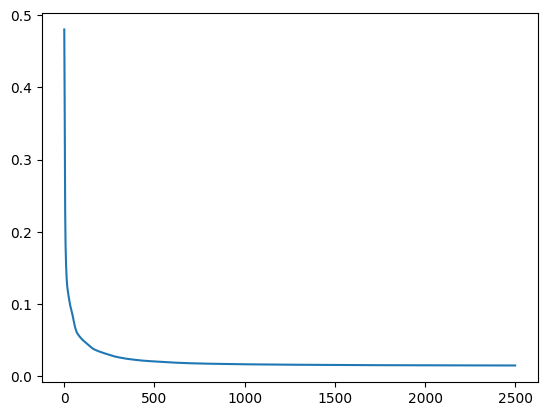

In [43]:
# we visualise the error
errors_reg = [float(err) for err in errors_reg]
plt.plot(errors_reg, label="Regular non-HALS")

In [64]:
# we create normalized variants of the factors
def normalize_factors(factors):
    normalized_factors = []
    for factor in factors:
        norm = torch.norm(factor, p=2, dim=0, keepdim=True)
        normalized_factor = factor / (norm + 1e-10)  # avoid division by zero
        normalized_factors.append(normalized_factor)
    return normalized_factors
factors_reg_n= normalize_factors(factors_reg)
factors_hals_n = normalize_factors(factors_hals)

In [32]:
def visualise_factors(factors, to_vis=None):
    if to_vis is None:
        to_vis = ["verb", "subject", "object"]
    factor_verb = factors[0].cpu()
    factor_subj = factors[1].cpu()
    factor_obj = factors[2].cpu()
    for i in range(factor_verb.shape[1]):
        print(f"Dimension {i}:")
        if "verb" in to_vis:
            # verbs
            top_values, top_indices = torch.topk(factor_verb[:, i], 10)
            top_verbs = [f"{vocab_v[idx]} ({top_values[j].item():.3f})" for j, idx in enumerate(top_indices)]
            print("verbs:", top_verbs)
        if "subject" in to_vis:
            # subjects
            top_values, top_indices = torch.topk(factor_subj[:, i], 10)
            top_subj = [f"{vocab_s[idx]} ({top_values[j].item():.3f})" for j, idx in enumerate(top_indices)]
            print("subjects:", top_subj)

        if "object" in to_vis:
            # objects
            top_values, top_indices = torch.topk(factor_obj[:, i], 10)
            top_obj = [f"{vocab_o[idx]} ({top_values[j].item():.3f})" for j, idx in enumerate(top_indices)]
            print("objects:", top_obj)

        print("\n")
visualise_factors(factors_reg_n)

Dimension 0:
verbs: ['willen (0.023)', 'denken (0.013)', 'gaan (0.013)', 'weten (0.011)', 'komen (0.006)', 'zeggen (0.005)', 'houden (0.003)', 'zitten (0.002)', 'zien (0.002)', 'horen (0.002)']
subjects: ['ik (0.995)', 'je (0.082)', 'u (0.034)', 'hij (0.026)', '~ (0.026)', 'ze (0.022)', 'we (0.021)', 'jij (0.005)', 'lk (0.003)', 'wij (0.002)']
objects: ['~ (1.000)', 'gang (0.001)', 'kant (0.000)', 'stad (0.000)', 'weg (0.000)', 'jongen (0.000)', 'kaart (0.000)', 'bak (0.000)', 'grens (0.000)', 'gevangenis (0.000)']


Dimension 1:
verbs: ['komen (0.013)', 'gaan (0.010)', 'kijken (0.007)', 'laten (0.007)', 'wachten (0.004)', 'doen (0.004)', 'blijven (0.004)', 'bedanken (0.004)', 'houden (0.003)', 'zeggen (0.002)']
subjects: ['~ (1.000)', 'we (0.009)', 'ze (0.009)', 'man (0.002)', 'jongen (0.002)', 'mens (0.002)', 'deze (0.001)', 'alles (0.001)', 'hij (0.001)', 'nee (0.000)']
objects: ['het (0.839)', 'dat (0.541)', 'niets (0.033)', '-dat (0.025)', 'niks (0.022)', 'wat (0.021)', 't. (0.015

In [41]:
visualise_factors(factors_reg_n)

Dimension 0:
verbs: ['willen (0.023)', 'gaan (0.013)', 'denken (0.013)', 'weten (0.011)', 'komen (0.006)', 'zeggen (0.005)', 'houden (0.003)', 'blijven (0.002)', 'zitten (0.002)', 'zien (0.002)']
subjects: ['ik (0.999)', 'je (0.025)', 'we (0.015)', '~ (0.013)', 'hij (0.012)', 'ze (0.009)', 'u (0.009)', 'iedereen (0.002)', 'jij (0.001)', 'dat (0.001)']
objects: ['~ (1.000)', 'gang (0.001)', 'kant (0.000)', 'stad (0.000)', 'weg (0.000)', 'jongen (0.000)', 'kaart (0.000)', 'bak (0.000)', 'grens (0.000)', 'huis (0.000)']


Dimension 1:
verbs: ['komen (0.013)', 'gaan (0.010)', 'laten (0.007)', 'kijken (0.007)', 'wachten (0.004)', 'doen (0.004)', 'blijven (0.004)', 'bedanken (0.004)', 'houden (0.003)', 'zeggen (0.002)']
subjects: ['~ (1.000)', 'ze (0.004)', 'we (0.002)', 'jongen (0.001)', 'man (0.001)', 'mens (0.001)', 'mr. (0.001)', 'deze (0.001)', 'nee (0.000)', 'hey (0.000)']
objects: ['het (0.840)', 'dat (0.541)', '-dat (0.025)', 'niets (0.022)', 'niks (0.019)', 't. (0.016)', 'wat (0.016

In [34]:
# we check the top dimensions for a few objects
factor_obj_reg = factors_reg_n[2].cpu()
factor_obj_hals = factors_hals_n[2].cpu()

target_objects = ["spel", "rol", "stad", "dorp", "lunch", "ontbijt", "boek", "film"]
# we first check if they are all in the vocab, else print a warning
top_dims = {word: {"reg":[], "hals":[]} for word in target_objects}
for target_obj in target_objects:
    if target_obj not in o2i:
        print(f"Warning: target object '{target_obj}' not in vocabulary")
    else:
        obj_idx = o2i[target_obj]
        obj_vector_reg = factor_obj_reg[obj_idx, :]
        obj_vector_hals = factor_obj_hals[obj_idx, :]
        # get top 5 dimensions for regular
        top_values_reg, top_indices_reg = torch.topk(obj_vector_reg, 5)
        top_dims_reg = [f"Dim {top_indices_reg[j].item()} ({top_values_reg[j].item():.3f})" for j in range(len(top_indices_reg))]
        top_dims[target_obj]["reg"] = top_dims_reg
        # get top 5 dimensions for hals
        top_values_hals, top_indices_hals = torch.topk(obj_vector_hals, 5)
        top_dims_hals = [f"Dim {top_indices_hals[j].item()} ({top_values_hals[j].item():.3f})" for j in range(len(top_indices_hals))]
        top_dims[target_obj]["hals"] = top_dims_hals


In [35]:
# we print in a clean, structured format
# WORD --- REGULAR TOP DIMS --- HALS TOP DIMS
print("WORD --- REGULAR TOP DIMS --- HALS TOP DIMS")
for word, dims in top_dims.items():
    reg_dims = ", ".join(dims["reg"])
    hals_dims = ", ".join(dims["hals"])
    print(f"{word} --- {reg_dims} --- {hals_dims}")


WORD --- REGULAR TOP DIMS --- HALS TOP DIMS
spel --- Dim 40 (0.025), Dim 27 (0.020), Dim 50 (0.012), Dim 23 (0.010), Dim 82 (0.009) --- Dim 86 (0.018), Dim 98 (0.013), Dim 76 (0.009), Dim 11 (0.009), Dim 60 (0.008)
rol --- Dim 93 (0.041), Dim 28 (0.030), Dim 81 (0.028), Dim 54 (0.021), Dim 90 (0.018) --- Dim 15 (0.025), Dim 4 (0.021), Dim 86 (0.017), Dim 91 (0.014), Dim 67 (0.013)
stad --- Dim 71 (0.039), Dim 73 (0.038), Dim 79 (0.033), Dim 45 (0.027), Dim 92 (0.024) --- Dim 0 (0.262), Dim 30 (0.048), Dim 71 (0.026), Dim 29 (0.010), Dim 64 (0.008)
dorp --- Dim 39 (0.019), Dim 45 (0.018), Dim 58 (0.012), Dim 54 (0.009), Dim 44 (0.007) --- Dim 81 (0.043), Dim 71 (0.013), Dim 98 (0.010), Dim 91 (0.009), Dim 86 (0.008)
lunch --- Dim 89 (0.025), Dim 99 (0.017), Dim 58 (0.016), Dim 30 (0.011), Dim 22 (0.011) --- Dim 64 (0.018), Dim 86 (0.014), Dim 58 (0.011), Dim 53 (0.006), Dim 31 (0.004)
ontbijt --- Dim 90 (0.072), Dim 30 (0.046), Dim 82 (0.040), Dim 42 (0.039), Dim 99 (0.036) --- Dim 64 (

In [36]:
all_dims = {"reg": set(), "hals": set()}
for word, dims in top_dims.items():
    for dim in dims["reg"]:
        dim_num = dim.split()[1]
        all_dims["reg"].add(dim_num)
    for dim in dims["hals"]:
        dim_num = dim.split()[1]
        all_dims["hals"].add(dim_num)
print("All unique top dimensions across target objects:")
print(sorted(all_dims["reg"]))
print(sorted(all_dims["hals"]))

All unique top dimensions across target objects:
['22', '23', '27', '28', '30', '39', '40', '42', '44', '45', '46', '50', '54', '58', '64', '68', '71', '73', '79', '81', '82', '89', '90', '92', '93', '94', '99']
['0', '10', '11', '15', '22', '29', '30', '31', '4', '53', '58', '60', '64', '66', '67', '7', '71', '76', '81', '83', '86', '91', '98']


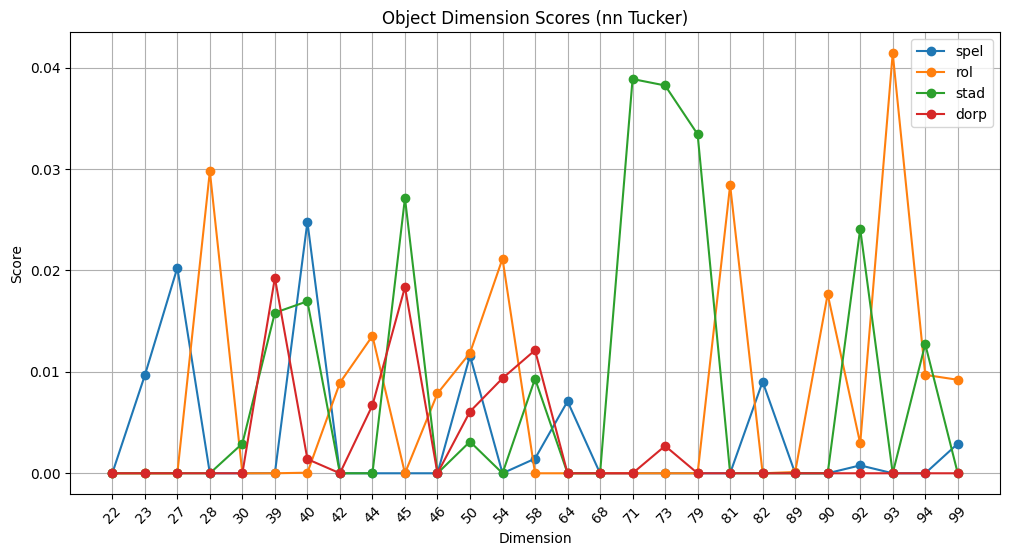

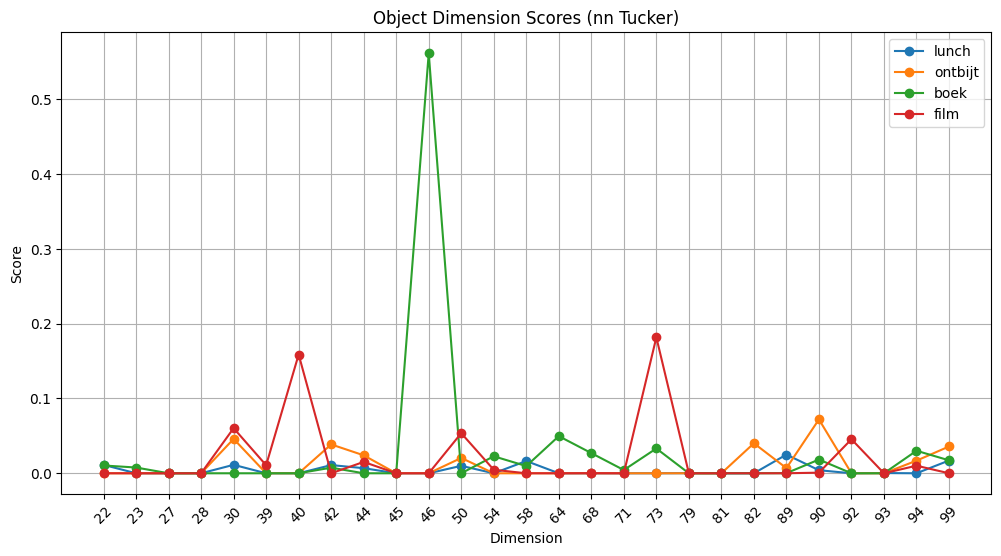

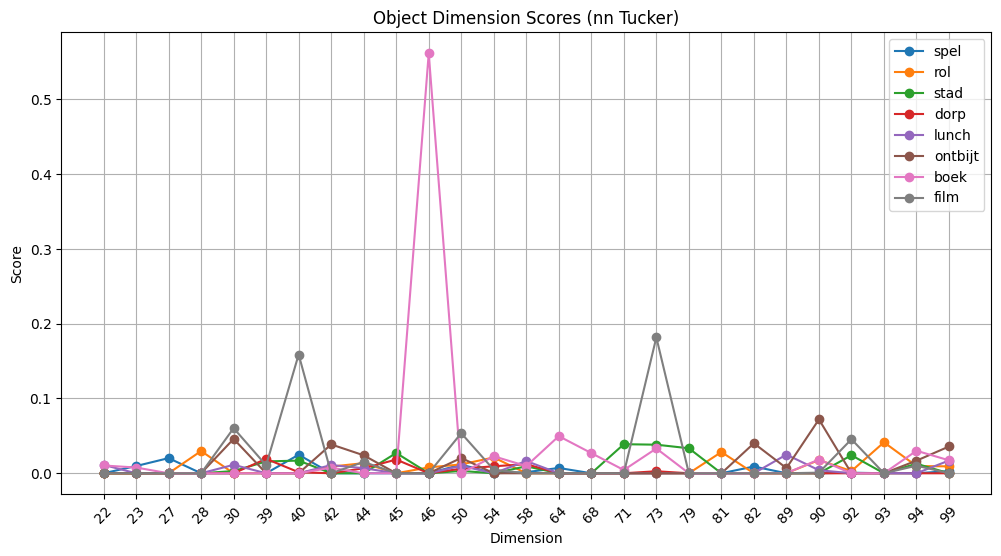

In [37]:
# we visualize the score per word on these dimensions
import numpy as np
import matplotlib.pyplot as plt

def plot_dimension_scores(factor, target_words, dimensions, title="Dimension Scores", role="verb"):
    all_dims = {"reg": set(), "hals": set()}
    for word, dims in top_dims.items():
        for dim in dims["reg"]:
            dim_num = dim.split()[1]
            all_dims["reg"].add(dim_num)
        for dim in dims["hals"]:
            dim_num = dim.split()[1]
            all_dims["hals"].add(dim_num)

    plt.figure(figsize=(12, 6))
    for target_word in target_words:
        if role == "verb":
            if target_word not in v2i:
                continue
            word_idx = v2i[target_word]
        elif role == "subject":
            if target_word not in s2i:
                continue
            word_idx = s2i[target_word]
        elif role == "object":
            if target_word not in o2i:
                continue
            word_idx = o2i[target_word]
        else:
            raise ValueError("role must be 'verb', 'subject', or 'object'")

        word_vector = factor[word_idx, :].cpu().numpy()
        scores = [word_vector[int(dim)] for dim in dimensions]
        plt.plot(dimensions, scores, marker='o', label=target_word)

    plt.title(title)
    plt.xlabel("Dimension")
    plt.ylabel("Score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid()
    plt.show()
plot_dimension_scores(factors_reg_n[2], target_objects[:4], sorted(all_dims["reg"]), title="Object Dimension Scores (nn Tucker)", role="object")
plot_dimension_scores(factors_reg_n[2], target_objects[4:], sorted(all_dims["reg"]), title="Object Dimension Scores (nn Tucker)", role="object")
plot_dimension_scores(factors_reg_n[2], target_objects, sorted(all_dims["reg"]), title="Object Dimension Scores (nn Tucker)", role="object")


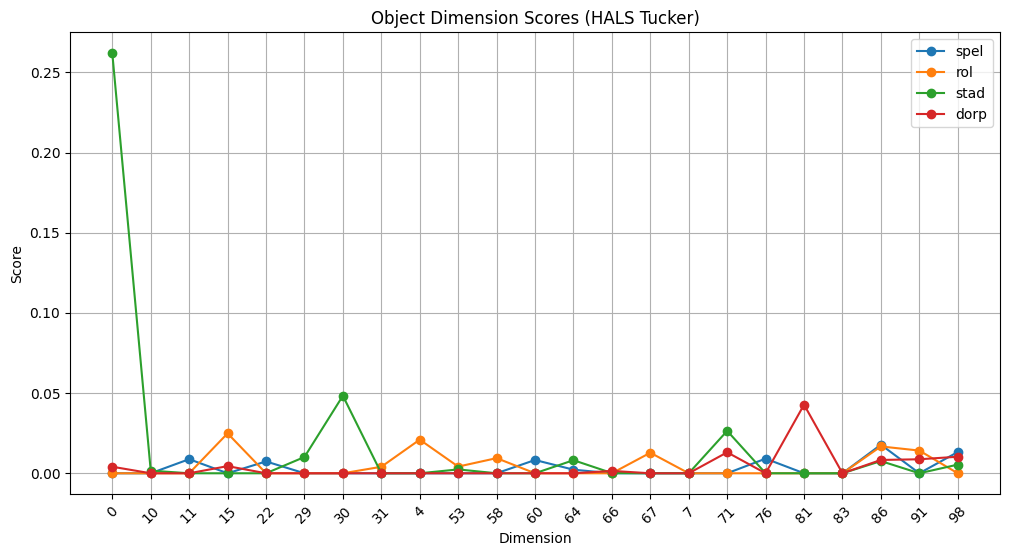

In [26]:
plot_dimension_scores(factors_hals_n[2], target_objects[:4], sorted(all_dims["hals"]), title="Object Dimension Scores (HALS Tucker)", role="object")

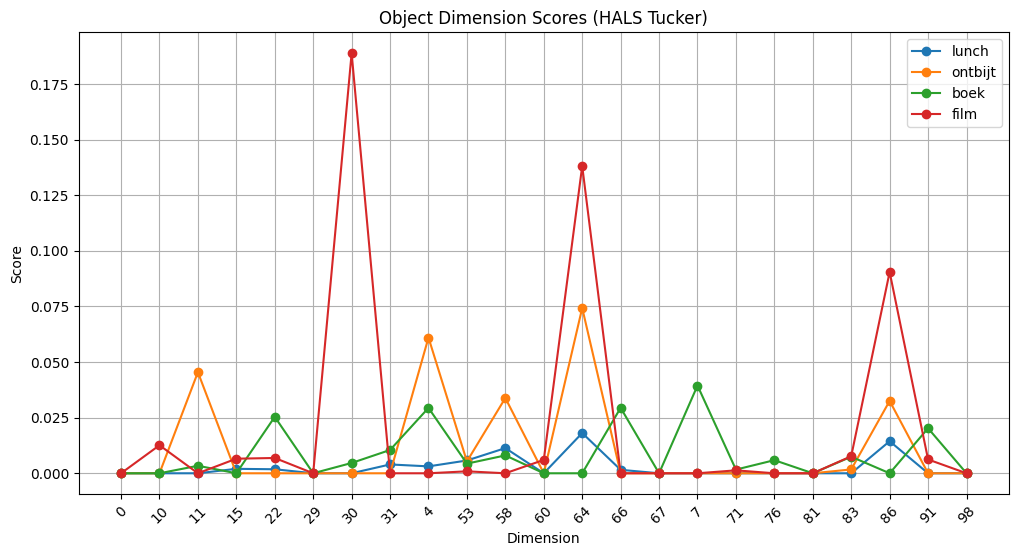

In [28]:
plot_dimension_scores(factors_hals_n[2], target_objects[4:], sorted(all_dims["hals"]), title="Object Dimension Scores (HALS Tucker)", role="object")

75000it [00:32, 2319.43it/s]


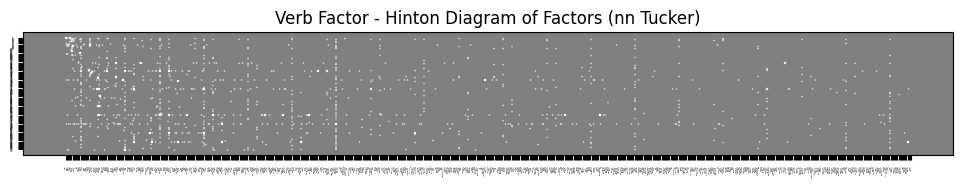

In [69]:
# we plot the factors as hinton diagrams
from tqdm import tqdm
def hinton(matrix, max_weight=None, ax=None):
    """Draw Hinton diagram for visualizing a weight matrix."""
    if ax is None:
        ax = plt.gca()
    if max_weight is None:
        max_weight = 2 ** np.ceil(np.log(np.abs(matrix).max()) / np.log(2))

    ax.patch.set_facecolor('gray')
    ax.set_aspect('equal', 'box')
    ax.xaxis.set_major_locator(plt.NullLocator())
    ax.yaxis.set_major_locator(plt.NullLocator())

    for (x, y), w in tqdm(np.ndenumerate(matrix)):
        color = 'white' if w > 0 else 'black'
        size = np.sqrt(np.abs(w) / max_weight)
        rect = plt.Rectangle([x - size / 2, y - size / 2], size, size,
                             facecolor=color, edgecolor=color)
        ax.add_patch(rect)

    ax.autoscale_view()
    ax.invert_yaxis()
    # we save the ax as well
    return ax
def plot_hinton_factors_together(factors, title="Hinton Diagram of Factors", save=True):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    roles = ["Verb", "Subject", "Object"]
    for i, (factor, role) in enumerate(tqdm(zip(factors, roles))):
        hinton(factor.cpu().numpy(), ax=axes[i])
        axes[i].set_title(f"{role} Factor")
        # we save these separately for higher definition
    plt.suptitle(title)
    plt.show()
    # we save as pdf with high resolution
    if save:
        fig.savefig(fDATA_DIR/"vis/{title.replace(' ', '_').lower()}.pdf", dpi=3000)
def plot_hinton_factor(factor, title="Hinton Diagram of Factor", role="Verb", axes=False, save=True):
    plt.figure(figsize=(12, 6))
    hinton(factor.cpu().numpy())
    plt.title(f"{role} Factor - {title}")
    if axes:
        # we map the vocab to the x-ax, and the numbered dimensions to the y-ax
        if role.lower() == "verb":
            voc = vocab_v
        elif role.lower() == "subject":
            voc = vocab_s
        elif role.lower() == "object":
            voc = vocab_o
        else:
            raise ValueError("role must be 'verb', 'subject', or 'object'")
        plt.xticks(ticks=np.arange(len(voc)), labels=voc, rotation=90, fontsize=1)
        plt.yticks(ticks=np.arange(factor.shape[1]), labels=[f"{i}" for i in range(factor.shape[1])], fontsize=2)

    if save:
        # we save as pdf with high resolution
        plt.savefig(fDATA_DIR/"vis/{role.lower()}_factor_{title.replace(' ', '_').lower()}{'_axes'if axes else ''}.pdf", dpi=3000)
    plt.show()
plot_hinton_factor(factors_reg[0], title="Hinton Diagram of Factors (nn Tucker)", role="Verb", axes=True)

In [83]:
# python
from math import ceil
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_colormap_factor(factor, title="Colormap of Factor", role="Verb",
                         axes=False, show=True, save=True, progress=False, chunk_size=128):
    """
    Plot colormap of a factor. If `progress=True` and `factor` is on GPU,
    copy to CPU in chunks while showing a tqdm progress bar to track transfer.
    """
    # prepare array (transfer in chunks if requested)
    if progress and isinstance(factor, torch.Tensor) and factor.is_cuda:
        rows, cols = factor.shape
        arr = np.empty((rows, cols), dtype=np.float32)
        total_chunks = ceil(cols / chunk_size)
        for i in tqdm(range(0, cols, chunk_size), desc="transferring columns", total=total_chunks):
            j = min(i + chunk_size, cols)
            arr[:, i:j] = factor[:, i:j].cpu().numpy()
    else:
        arr = factor.cpu().numpy() if isinstance(factor, torch.Tensor) else np.array(factor)

    plt.figure(figsize=(24, 12))
    plt.imshow(arr, aspect='auto', cmap='viridis')
    plt.colorbar(label='Value')
    plt.title(f"{role} Factor - {title}")

    if axes:
        # map vocab to x-axis and dimension numbers to y-axis
        if role.lower() == "verb":
            voc = vocab_v
        elif role.lower() == "subject":
            voc = vocab_s
        elif role.lower() == "object":
            voc = vocab_o
        else:
            raise ValueError("role must be 'verb', 'subject', or 'object'")

        # build xtick labels with optional progress
        if progress and len(voc) > 500:
            labels = []
            for label in tqdm(voc, desc="building xtick labels"):
                labels.append(label)
        else:
            labels = list(voc)

        plt.yticks(ticks=np.arange(len(voc)), labels=labels, fontsize=1)
        plt.xticks(ticks=np.arange(arr.shape[1]), rotation=90, labels=[f"{i}" for i in range(arr.shape[1])], fontsize=2)
    print("built")
    if save:
        plt.savefig(fDATA_DIR/"vis/{role.lower()}_factor_colormap_{title.replace(' ', '_').lower()}{'_axes'if axes else ''}.pdf", dpi=2000)
    print("saved")
    if show:
        plt.show()

In [ ]:
# we make a new normalised factor, in which we use the column-wise norm to normalise
factors_reg_bis = []
for factor in factors_reg:
    norm = torch.norm(factor, p=2, dim=1, keepdim=True)
    normalized_factor = factor / (norm + 1e-10)  # avoid division by zero
    factors_reg_bis.append(normalized_factor)
plot_colormap_factor(factors_reg_bis[0], title="Normalized (nn Tucker) bis", role="Verb", show=False, axes=True, progress=True)

building xtick labels: 100%|██████████| 750/750 [00:00<00:00, 5607358.29it/s]


built
